# 10. Watching the solver work

The solver supports three observability features that turn it from a black box into a debugging tool. This notebook exercises each in turn.

- `verbose=0|1|2` controls live printing: silent, end-of-solve summary, or per-iteration progress feed.
- `trace=True` collects a structured `TraceEntry` per iteration on `result.trace`. Useful for plotting convergence behaviour or writing regression tests on iteration counts.
- `on_iteration=callable` is invoked with each `TraceEntry` as it is produced, useful for live plotting or custom logging.

And the `result.status` field (`"converged"`, `"max_iter"`, `"diverged"`) distinguishes the solver's termination reason from `result.feasible` (which is about the answer, not the iteration).


## A small drone for testing

In [1]:
from codesign import Module, Reals, System, solve

# Minimal two-subsystem drone for exercising the observability features.
class Battery(Module):
    F = {"capacity": Reals(unit="J")}
    R = {"mass":     Reals(unit="kg")}
    def h(self, f):
        return {"mass": f["capacity"] / 1.8e6}

class Actuator(Module):
    F = {"lift_force": Reals(unit="N")}
    R = {"power":      Reals(unit="W")}
    def h(self, f):
        return {"power": 10.0 * f["lift_force"] ** 2}

sys = System("drone")
endurance     = sys.provides("endurance",     unit="s")
extra_payload = sys.provides("extra_payload", unit="kg")
extra_power   = sys.provides("extra_power",   unit="W")
total_mass    = sys.requires("total_mass",    unit="kg")
b = sys.add("battery",  Battery())
a = sys.add("actuator", Actuator())
# Same three-line wiring as notebook 07.
b.capacity    >= (a.power + extra_power) * endurance
a.lift_force  >= 9.81 * (b.mass + extra_payload)
total_mass    >= b.mass + extra_payload
drone = sys.build()
# Fixed mission used everywhere in this notebook.
f = {"endurance": 300.0, "extra_payload": 0.5, "extra_power": 5.0}

## verbose=1: a one-line summary

In [2]:
_ = solve(drone, f, verbose=1)

[solve] converged: 43 iters, |A|=1, total=1.1ms, feasible=True


## verbose=2: a per-iteration feed

In [3]:
_ = solve(drone, f, verbose=2, max_iter=10)

[solve] iter    0: |A|=1   delta=    -      t=0.00ms
[solve] iter    1: |A|=1   delta=5.008e-01  t=0.03ms
[solve] iter    2: |A|=1   delta=4.010e-02  t=0.02ms
[solve] iter    3: |A|=1   delta=1.338e-04  t=0.03ms
[solve] iter    4: |A|=1   delta=6.700e-03  t=0.02ms
[solve] iter    5: |A|=1   delta=2.322e-05  t=0.02ms
[solve] iter    6: |A|=1   delta=1.170e-03  t=0.02ms
[solve] iter    7: |A|=1   delta=4.079e-06  t=0.02ms
[solve] iter    8: |A|=1   delta=2.058e-04  t=0.02ms
[solve] iter    9: |A|=1   delta=7.184e-07  t=0.02ms
[solve] iter   10: |A|=1   delta=3.625e-05  t=0.02ms
[solve] max_iter: 10 iters, |A|=1, total=0.4ms, feasible=True


## trace=True: collect the iterations as data

The trace is a list of `TraceEntry` objects, one per iteration (plus the seed at iteration 0). Each carries the antichain at that step, the number of points, the convergence delta (max absolute change in any port value), and the wall time spent on that step alone.


In [4]:
r = solve(drone, f, trace=True, max_iter=200)
print(f"status={r.status}, iters={r.iterations}, feasible={r.feasible}")
print(f"trace has {len(r.trace)} entries (iteration 0 = seed, then 1..N)")
print(f"first 5 deltas: {[e.delta for e in r.trace[:5]]}")
print(f"final delta: {r.trace[-1].delta}")

status=converged, iters=43, feasible=True
trace has 44 entries (iteration 0 = seed, then 1..N)
first 5 deltas: [None, 0.5008333333333334, 0.04009837500000002, 0.00013377263437497344, 0.0067001313574891475]
final delta: 0.0


## Plotting the convergence

The `codesign.viz` module provides `plot_convergence` as a one-liner; for this drone the deltas oscillate between two coupled axes (battery mass and actuator power) and decay to roughly machine precision.


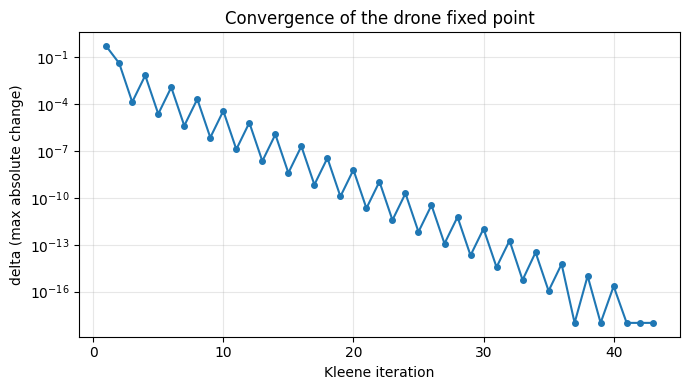

In [5]:
import matplotlib.pyplot as plt
from codesign import viz

ax = viz.plot_convergence(r)
ax.set_title("Convergence of the drone fixed point")
plt.tight_layout()
plt.show()

## on_iteration: a custom callback

The callback receives each `TraceEntry` as it is produced. The drone here is small, so we print every 5th iteration to keep things tidy. In a real GUI or notebook plotter you'd update a live figure instead.


In [6]:
def my_logger(entry):
    if entry.iteration % 5 == 0:
        d = "    -    " if entry.delta is None else f"{entry.delta:.3e}"
        print(f"   iter {entry.iteration:>3}: |A|={entry.n_points}, delta={d}")

_ = solve(drone, f, on_iteration=my_logger, max_iter=100)

   iter   0: |A|=1, delta=    -    
   iter   5: |A|=1, delta=2.322e-05
   iter  10: |A|=1, delta=3.625e-05
   iter  15: |A|=1, delta=3.928e-09
   iter  20: |A|=1, delta=6.154e-09
   iter  25: |A|=1, delta=6.668e-13
   iter  30: |A|=1, delta=1.044e-12
   iter  35: |A|=1, delta=1.110e-16
   iter  40: |A|=1, delta=2.220e-16


## status vs feasible

The `status` field describes the solver's termination reason. The `feasible` field describes the answer. They are orthogonal: a solve can terminate cleanly on an infeasible problem, and a max-iter cut might leave a still-converging-but-feasible run looking suspect.


In [7]:
# A run cut short:
r_short = solve(drone, f, max_iter=3)
print(f"max_iter=3:  status={r_short.status!r}, feasible={r_short.feasible}, iters={r_short.iterations}")

# A clean converged run:
r_ok = solve(drone, f, max_iter=200)
print(f"max_iter=200: status={r_ok.status!r}, feasible={r_ok.feasible}, iters={r_ok.iterations}")

# A genuinely infeasible run (too long an endurance for the battery):
r_inf = solve(drone, {"endurance": 1800.0, "extra_payload": 1.0, "extra_power": 10.0}, max_iter=200)
print(f"infeasible:  status={r_inf.status!r}, feasible={r_inf.feasible}, iters={r_inf.iterations}")

max_iter=3:  status='max_iter', feasible=True, iters=3
max_iter=200: status='converged', feasible=True, iters=43
infeasible:  status='diverged', feasible=False, iters=16


The third case is interesting: the solver detects numerical divergence (some port value crossing the divergence cap of 1e30) and stops with `status='diverged'`, which is more informative than just `feasible=False`. With only the feasible flag you couldn't tell whether bumping `max_iter` would help.
